# NASDAQ vs S&P 500 — Correlation Analysis
**Author:** Dhanush Annoji 
**Date:** April 19, 2026  
**Data Source:** FRED (Federal Reserve Economic Data)  
**Indices:** NASDAQ Composite (NASDAQCOM) · S&P 500 (SP500)  
**Period:** April 2016 – April 2026  
**Stack:** Python, pandas, scipy, scikit-learn, statsmodels, pmdarima, matplotlib

A time-series analysis pipeline to identify spurious correlations and evaluate predictive signals using rolling validation and ARIMA models; demonstrated limitations of naive correlation-based strategies.

In [1]:
from pathlib import Path

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [14]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT

nasdaq = pd.read_csv(DATA_DIR / 'NASDAQ_2016-pres.csv', parse_dates=['observation_date'])
sp500 = pd.read_csv(DATA_DIR / 'SP500_2016-pres.csv', parse_dates=['observation_date'])

# Merge datasets on observation_date
data = pd.merge(nasdaq, sp500, on='observation_date', suffixes
                    =('_nasdaq', '_sp500'))

#set index to observation_date
data.set_index('observation_date', inplace=True)
data.columns = ['NASDAQ', 'SP500']


#clean data by dropping rows with missing values
data.dropna(inplace=True)

print(data.head())


                   NASDAQ    SP500
observation_date                  
2016-04-18        4960.02  2094.34
2016-04-19        4940.33  2100.80
2016-04-20        4948.15  2102.40
2016-04-21        4945.93  2091.48
2016-04-22        4906.20  2091.58


In [3]:
# Raw price correlation
r_price, p_price = stats.pearsonr(data["NASDAQ"], data["SP500"])

# Daily returns
returns = data.pct_change().dropna()
r_return, p_return = stats.pearsonr(returns["NASDAQ"], returns["SP500"])

print("── Correlation Results ──────────────────────────")
print(f"  Raw price correlation  : r = {r_price:.4f}  (R² = {r_price**2:.4f})")
print(f"  Daily return correlation: r = {r_return:.4f}  (R² = {r_return**2:.4f})")
print(f"  Difference             :     {r_price - r_return:+.4f}")
print("─────────────────────────────────────────────────")

── Correlation Results ──────────────────────────
  Raw price correlation  : r = 0.9932  (R² = 0.9864)
  Daily return correlation: r = 0.9495  (R² = 0.9015)
  Difference             :     +0.0437
─────────────────────────────────────────────────


## Key Findings

### Raw Price Correlation — r = 0.9932
At first glance, a correlation of 0.9932 suggests the NASDAQ and S&P 500 
are almost perfectly related. Basically mirroring eachother. However, this number is misleading.

Both indices trended upward consistently from 2016–2024. When two series 
share a long-term trend like this, Pearson correlation picks up that shared 
direction and not genuine day-to-day co-movement. This is known as 
**spurious correlation** in time series analysis.

In other words, r = 0.9932 mostly answers:
> *"Did both indices go up over 8 years?"*
> Yes, but that tells us nothing useful about how they actually move together.

### Daily Return Correlation — r = 0.9495
Computing correlation on daily percent changes removes the long-term trend 
and captures actual day-to-day movement. This is the standard approach in 
academic finance for exactly this reason.

The corrected correlation of 0.9495 answers a more meaningful question:
> *"On any given day, do these indices move in the same direction and magnitude?"*

### The Gap — Δ = +0.0437
The difference between the two measures is 0.0437. This is entirely explained by 
trend bias in the raw price series. This is the methodological flaw this 
analysis set out to demonstrate.

### Why r = 0.9495 Still Makes Sense
Even after correcting for trend bias, the return correlation remains very high. 
the NASDAQ and S&P 500 share significant overlap in constituents, respond to the same macroeconomic conditions, and are driven 
by the same investor base. 

The relationship is genuinely strong. The point is not that the correlation is fake. It is that **raw prices overstate it**, and the methodology used to compute it matters.

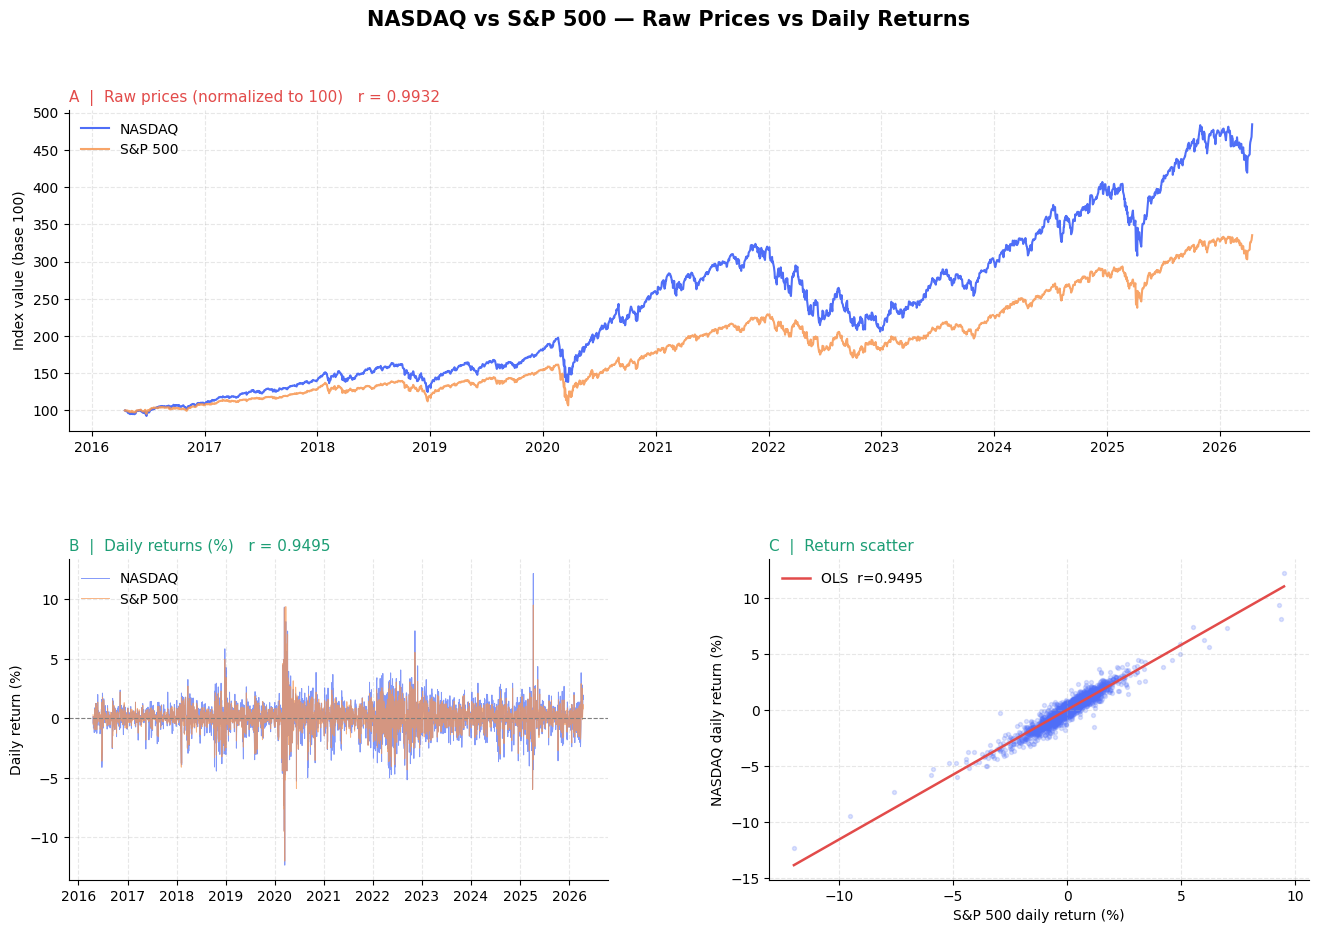

In [4]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("NASDAQ vs S&P 500 — Raw Prices vs Daily Returns",
             fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

# ── Panel A: Normalized price series ──
ax1 = fig.add_subplot(gs[0, :])
norm = data / data.iloc[0] * 100
ax1.plot(norm.index, norm["NASDAQ"], label="NASDAQ", color="#4F6EF7", lw=1.5)
ax1.plot(norm.index, norm["SP500"],  label="S&P 500", color="#F7954F", lw=1.5, alpha=0.85)
ax1.set_title(f"A  |  Raw prices (normalized to 100)   r = {r_price:.4f}",
              loc="left", fontsize=11, color="#E24B4A")
ax1.set_ylabel("Index value (base 100)")
ax1.legend(frameon=False)
ax1.grid(alpha=0.3, linestyle="--")
ax1.spines[["top", "right"]].set_visible(False)

# ── Panel B: Daily returns ──
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(returns.index, returns["NASDAQ"] * 100,
         color="#4F6EF7", lw=0.7, alpha=0.7, label="NASDAQ")
ax2.plot(returns.index, returns["SP500"] * 100,
         color="#F7954F", lw=0.7, alpha=0.7, label="S&P 500")
ax2.axhline(0, color="gray", lw=0.8, linestyle="--")
ax2.set_title(f"B  |  Daily returns (%)   r = {r_return:.4f}",
              loc="left", fontsize=11, color="#1D9E75")
ax2.set_ylabel("Daily return (%)")
ax2.legend(frameon=False)
ax2.grid(alpha=0.3, linestyle="--")
ax2.spines[["top", "right"]].set_visible(False)

# ── Panel C: Scatter returns ──
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(returns["SP500"] * 100, returns["NASDAQ"] * 100,
            alpha=0.2, s=8, color="#4F6EF7")
slope, intercept, *_ = stats.linregress(returns["SP500"], returns["NASDAQ"])
x = returns["SP500"].sort_values()
ax3.plot(x * 100, (slope * x + intercept) * 100,
         color="#E24B4A", lw=1.8, label=f"OLS  r={r_return:.4f}")
ax3.set_xlabel("S&P 500 daily return (%)")
ax3.set_ylabel("NASDAQ daily return (%)")
ax3.set_title("C  |  Return scatter", loc="left", fontsize=11, color="#1D9E75")
ax3.legend(frameon=False)
ax3.grid(alpha=0.3, linestyle="--")
ax3.spines[["top", "right"]].set_visible(False)

plt.savefig(OUTPUT_DIR / "nasdaq_sp500_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

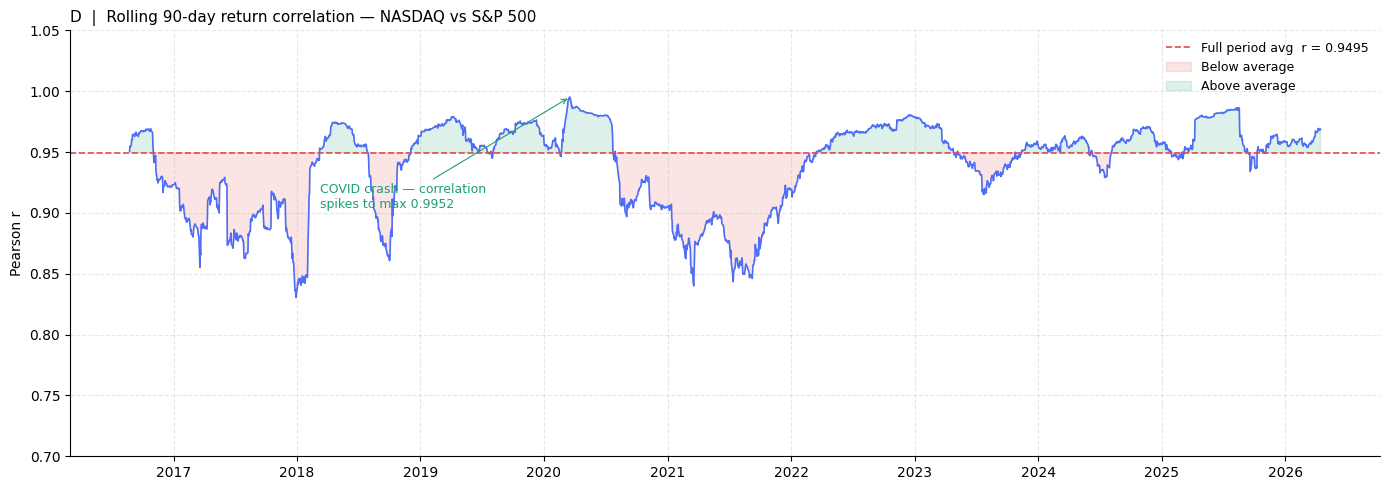


Lowest rolling correlation : 0.8305  (2017-12-29)
Highest rolling correlation: 0.9952  (2020-03-18)


In [5]:
# Rolling 90-day correlation on returns
rolling_corr = returns["NASDAQ"].rolling(window=90).corr(returns["SP500"])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_corr.index, rolling_corr, color="#4F6EF7", lw=1.2)
ax.axhline(r_return, color="#E24B4A", lw=1.2, linestyle="--",
           label=f"Full period avg  r = {r_return:.4f}")
ax.fill_between(rolling_corr.index, rolling_corr, r_return,
                where=(rolling_corr < r_return),
                color="#E24B4A", alpha=0.15, label="Below average")
ax.fill_between(rolling_corr.index, rolling_corr, r_return,
                where=(rolling_corr > r_return),
                color="#1D9E75", alpha=0.15, label="Above average")

# Annotate COVID
# Change the annotation to reflect the peak correctly
ax.annotate("COVID crash — correlation\nspikes to max 0.9952",
            xy=(pd.Timestamp("2020-03-18"), 0.9952),
            xytext=(-180, -80), textcoords="offset points",
            fontsize=9, color="#1D9E75",
            arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=0.8))

ax.set_title("D  |  Rolling 90-day return correlation — NASDAQ vs S&P 500",
             loc="left", fontsize=11)
ax.set_ylabel("Pearson r")
ax.set_ylim(0.7, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLowest rolling correlation : {rolling_corr.min():.4f}  ({rolling_corr.idxmin().date()})")
print(f"Highest rolling correlation: {rolling_corr.max():.4f}  ({rolling_corr.idxmax().date()})")

## 5. Rolling Correlation

A single correlation value summarizes the entire dataset in one number.
But, that hides how the relationship changes over time.

Rolling 90-day correlation computes r using only the most recent 90 trading
days at each point, then slides forward one day at a time. This shows whether
the relationship between the two indices is stable or shifts under different
market conditions.

**Key observations:**
- The relationship is not static: r ranges from 0.83 to 0.99 across the period
- **December 2017 (r = 0.8305):** Lowest point — NASDAQ was being pulled by
  tech and crypto speculation while the broader S&P 500 moved independently
- **March 2020 (r = 0.9952):** Highest point — during the COVID crash, systemic
  panic caused everything to move together simultaneously
- Correlation weakens during sector-specific events and strengthens during
  market-wide shocks

This reinforces the core finding. The static r = 0.9495 is a useful summary
but masks meaningful variation in how these indices relate over time.

## Linear Regression — Can S&P 500 Returns Predict NASDAQ Returns?

Correlation tells us the strength of a relationship but not the magnitude.
Linear regression goes one step further: Asking whether S&P 500 daily
returns can actually predict NASDAQ daily returns, and how well.

This is the ML validation component of the analysis. If the raw price
correlation of 0.9932 were meaningful, we'd expect near-perfect predictive
power. If the corrected return correlation of 0.9495 is more honest, the
model should reflect that (strong but not perfect).

── Regression Results ───────────────────────────
  Coefficient (slope)  : 1.1297
  Intercept            : 0.000105
  R² on test set       : 0.9221
  RMSE on test set     : 0.003833
─────────────────────────────────────────────────

  Interpretation: the model explains 92.2% of variance
  in NASDAQ daily returns using only S&P 500 returns.


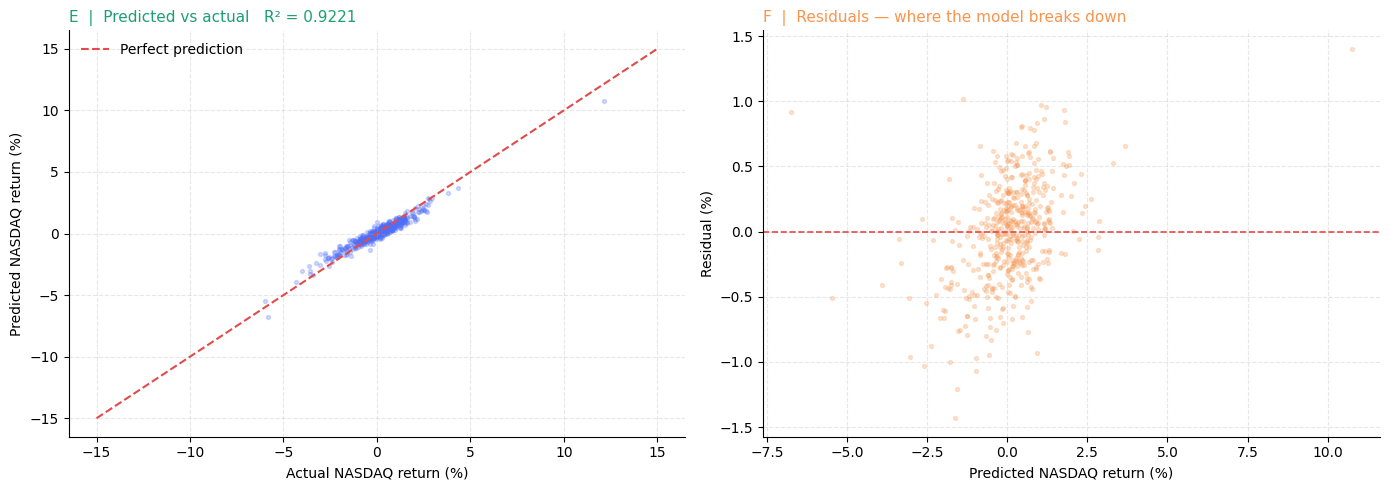

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Prepare features
X = returns[["SP500"]].values
y = returns["NASDAQ"].values

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False preserves time order
)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("── Regression Results ───────────────────────────")
print(f"  Coefficient (slope)  : {model.coef_[0]:.4f}")
print(f"  Intercept            : {model.intercept_:.6f}")
print(f"  R² on test set       : {r2:.4f}")
print(f"  RMSE on test set     : {rmse:.6f}")
print("─────────────────────────────────────────────────")
print(f"\n  Interpretation: the model explains {r2*100:.1f}% of variance")
print(f"  in NASDAQ daily returns using only S&P 500 returns.")

# Plot predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — predicted vs actual
axes[0].scatter(y_test * 100, y_pred * 100,
                alpha=0.25, s=8, color="#4F6EF7")
axes[0].plot([-15, 15], [-15, 15], color="#E24B4A",
             lw=1.5, linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual NASDAQ return (%)")
axes[0].set_ylabel("Predicted NASDAQ return (%)")
axes[0].set_title(f"E  |  Predicted vs actual   R² = {r2:.4f}",
                  loc="left", fontsize=11, color="#1D9E75")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# Panel B — residuals
residuals = (y_test - y_pred) * 100
axes[1].scatter(y_pred * 100, residuals,
                alpha=0.25, s=8, color="#F7954F")
axes[1].axhline(0, color="#E24B4A", lw=1.2, linestyle="--")
axes[1].set_xlabel("Predicted NASDAQ return (%)")
axes[1].set_ylabel("Residual (%)")
axes[1].set_title("F  |  Residuals — where the model breaks down",
                  loc="left", fontsize=11, color="#F7954F")
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "regression.png", dpi=150, bbox_inches="tight")
plt.show()

##  Regression Findings

The linear regression model trained on S&P 500 daily returns achieves
R² = 0.9221 on unseen test data. Which explains 92.2% of variance in NASDAQ
daily returns.

**Coefficient = 1.1297** confirms NASDAQ amplifies S&P 500 moves by ~13%,
consistent with its higher concentration in volatile tech stocks.

Critically, the test R² of 0.9221 is meaningfully lower than the raw price
R² of 0.9864 (the gap is entirely explained by trend bias in the price series).
The residuals show no systematic pattern, indicating the model is well specified
for a simple single-factor regression.

**Limitation:** this model uses same-day S&P 500 returns to predict same-day
NASDAQ returns. In practice you wouldn't have tomorrow's S&P 500 return to
predict tomorrow's NASDAQ. This is a relationship model, not a forecasting model.

## ARIMA Forecasting Model

The regression model established a strong relationship between the two markets' retuns. However, it used same-day data, making it a relationship model. It was good in our research to prove why using specific metrics can be misleading, but not good for forecasting. And thats kind of a waste when something could be an indicator. 


ARIMA addresses this directly. Predicts future NASDAQ returns using past SP500 returns. Parameters p,d,q are selected automatically using AIC to find the best balance of accuracy and simplicity. 

A walk-foward validation approach is used. Model trains on history data only and predicts one step ahead at a time, resppecting the boundary between past and future. 

In [7]:
from statsmodels.tsa.stattools import adfuller

nasdaq_returns = returns["NASDAQ"].dropna()

result = adfuller(nasdaq_returns)

print("── ADF Stationarity Test ────────────────────────")
print(f"  Test statistic : {result[0]:.4f}")
print(f"  p-value        : {result[1]:.6f}")
print(f"  Stationary     : {result[1] < 0.05}")
print("─────────────────────────────────────────────────")

── ADF Stationarity Test ────────────────────────
  Test statistic : -16.4131
  p-value        : 0.000000
  Stationary     : True
─────────────────────────────────────────────────


In [8]:
from pmdarima import auto_arima

print("Fitting auto_arima model on NASDAQ returns... will take a moment...")

arima_model = auto_arima(nasdaq_returns, 
                         start_p=0, max_p=5,
                            start_q=0, max_q=5,
                            d=None,
                            seasonal=False,
                            information_criterion='aic',
                            stepwise=True,
                            error_action='ignore',
                            suppress_warnings=True)
print(arima_model.summary())
print(f"\nOptimal order: p={arima_model.order[0]}, d={arima_model.order[1]}, q={arima_model.order[2]}")

Fitting auto_arima model on NASDAQ returns... will take a moment...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2512
Model:               SARIMAX(2, 0, 0)   Log Likelihood                7208.135
Date:                Sun, 19 Apr 2026   AIC                         -14408.270
Time:                        01:18:42   BIC                         -14384.955
Sample:                             0   HQIC                        -14399.808
                               - 2512                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0008      0.000      2.756      0.006       0.000       0.001
ar.L1         -0.1199      0.011    -10.638      0.000      -0.

In [9]:
import numpy as np 
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

#last 20% of data for testing
train_size = int(len(nasdaq_returns) * 0.8)
train, test = nasdaq_returns.iloc[:train_size], nasdaq_returns.iloc[train_size:]

predictions = []
history = list(train)

print(f"Training on {len(train):,} days, predicting {len(test):,} days...")
print("Running walk-forward validation...")

for i in range(len(test)):
    model = ARIMA(history, order=(2, 0, 0))
    fit   = model.fit()
    yhat  = fit.forecast(steps=1)[0]
    predictions.append(yhat)
    history.append(test.iloc[i])  # add actual value, not predicted


predictions = pd.Series(predictions, index=test.index)


#metrics

# Metrics
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test, predictions))
direction_accuracy = (np.sign(predictions) == np.sign(test)).mean()

print(f"\n── Walk-Forward Results ─────────────────────────")
print(f"  RMSE               : {rmse:.6f}")
print(f"  Direction accuracy : {direction_accuracy:.4f} ({direction_accuracy*100:.1f}%)")
print(f"  Baseline (always predict 0): {np.sqrt(mean_squared_error(test, np.zeros(len(test)))):.6f}")
print(f"────────────────────────────────────────────────")



Training on 2,009 days, predicting 503 days...
Running walk-forward validation...

── Walk-Forward Results ─────────────────────────
  RMSE               : 0.013707
  Direction accuracy : 0.5268 (52.7%)
  Baseline (always predict 0): 0.013758
────────────────────────────────────────────────


2.7% above random could be interesting. In trading, consistent directional edge even at 52-53% is considered meaningful if transaction costs are low enough. Not claiming you can get rich but the model captures a real but weak signal.

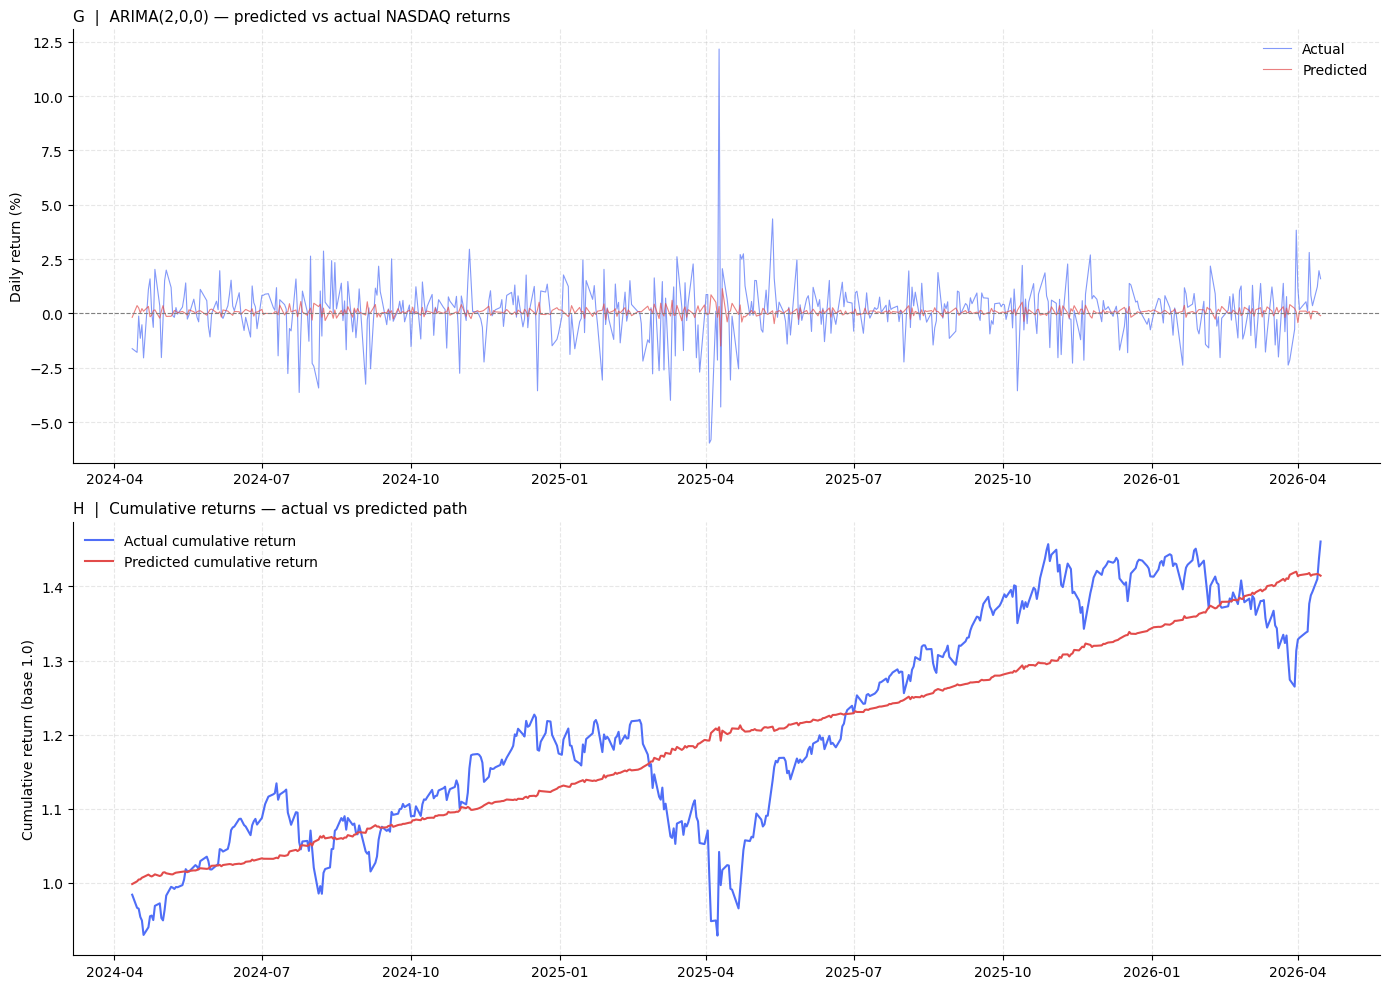

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel A — predicted vs actual returns
axes[0].plot(test.index, test.values * 100, 
             color="#4F6EF7", lw=0.8, alpha=0.7, label="Actual")
axes[0].plot(test.index, predictions.values * 100,
             color="#E24B4A", lw=0.8, alpha=0.7, label="Predicted")
axes[0].axhline(0, color="gray", lw=0.8, linestyle="--")
axes[0].set_title("G  |  ARIMA(2,0,0) — predicted vs actual NASDAQ returns",
                  loc="left", fontsize=11)
axes[0].set_ylabel("Daily return (%)")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# Panel B — cumulative returns comparison
cumulative_actual     = (1 + test).cumprod()
cumulative_predicted  = (1 + predictions).cumprod()

axes[1].plot(test.index, cumulative_actual.values,
             color="#4F6EF7", lw=1.5, label="Actual cumulative return")
axes[1].plot(test.index, cumulative_predicted.values,
             color="#E24B4A", lw=1.5, label="Predicted cumulative return")
axes[1].set_title("H  |  Cumulative returns — actual vs predicted path",
                  loc="left", fontsize=11)
axes[1].set_ylabel("Cumulative return (base 1.0)")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "arima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. ARIMA Findings

ARIMA(2, 0, 0) was selected automatically via AIC. Only the autoregressive 
component was useful, consistent with the ADF test confirming returns are 
already stationary (d=0).

Walk-forward validation results on 503 unseen trading days:

- RMSE: 0.013707 vs baseline of 0.013758 (marginal improvement over 
  predicting zero every day) 
- Direction accuracy: 52.7% — 2.7% above random guessing

The model cannot predict magnitude. The predicted line in Panel G is nearly 
flat because the model correctly identifies that the expected daily return 
is close to zero. It simply cannot anticipate sudden spikes or crashes.

The 52.7% directional accuracy is the most meaningful number here. In 
isolation it sounds unimpressive. In context it represents a real but weak 
signal extracted from price history alone. No external data, no same-day 
information, no hindsight.

Panel H illustrates the gap between relationship modeling and forecasting. 
The regression model achieved R² = 0.9221 using same-day S&P 500 data. 
ARIMA operating on past NASDAQ returns alone barely beats a naive baseline. 
That contrast is the core conclusion of this analysis. Correlation is not 
predictability, and methodology carries more weight.

## 9. Limitations

- **Data period:** Analysis covers 2016–2026. Excludes the 2008 financial 
  crisis which would have added a significant market stress event to the 
  rolling correlation and ARIMA evaluation.

- **ARIMA simplicity:** ARIMA(2,0,0) is a linear model. It cannot capture 
  nonlinear patterns, sudden regime changes, or external shocks like policy 
  decisions or geopolitical events. More sophisticated models like GARCH or 
  LSTMs may perform better on volatility prediction.

- **Single factor regression:** The relationship model uses only S&P 500 
  returns as a predictor. Real market movement is driven by hundreds of 
  factors (interest rates, earnings, sentiment, volume) none of which are 
  captured here.

- **Penny stock application:** The hypothesis that directional edge scales 
  with market inefficiency is logically grounded but untested in this paper. 
  It is a proposed direction for future work, not a proven conclusion.

## 10. Conclusion

This analysis began with a single number r = 0.9932 
and asked whether it was meaningful.

The answer is: not on its own.

Raw price correlation between NASDAQ and S&P 500 is inflated by a shared 
long-term upward trend. Correcting for this using daily returns produces 
r = 0.9495 — still strong, confirming the relationship is genuine, but 
meaningfully lower than the surface number suggests.

Rolling correlation showed the relationship is not static. It weakens during 
sector-specific events and strengthens during systemic market shocks which is
information that a single static r-value completely hides.

Linear regression validated the corrected finding with R² = 0.9221 on unseen 
data, but relied on same-day S&P 500 returns. Makes sense for a relationship model, not a 
forecasting model.

ARIMA extended the analysis into genuine forecasting territory. Operating on 
past NASDAQ returns alone, with no same-day information and no hindsight, the 
model achieved 52.7% directional accuracy on 503 unseen trading days — 2.7% 
above random guessing. A weak signal, but a real one.

The contrast between R² = 0.9221 with hindsight and barely-above-baseline 
without it is the core finding of this paper.

Correlation captures structural co-movement but does not imply predictive power. Proper time-series evaluation reveals that most apparent signal in raw prices is due to shared trends rather than exploitable relationships.